# Реализация статистических тестов

## Подключим библиотеки для работы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

## Подготовим данные для начала

Перед проверкой гипотез лучше нам еще раз убедиться, что с данными все в порядке, нет дубликатов, пропусков, что названия колонок корректны

In [2]:
data = pd.read_csv('data.csv', sep=';')

In [3]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
data.shape

(4424, 37)

#### Проверка колонок

In [5]:
data.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [6]:
data.columns = data.columns.str.strip()

In [7]:
data.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

#### Дубликаты и пропуски

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.isna().sum().sum()

np.int64(0)

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

В датасете 4424 наблюдения и 37 колонок. Полных дубликатов и пропущенных значений не обнаружено.  
Названия колонок были очищены от лишних пробелов

#### Посмотрим на целевую переменную

Целевая переменная `Target` имеет три категории:
- `Dropout` = студент отчислился
- `Graduate` = студент окончил обучение
- `Enrolled` = студент все еще обучается

Посмотрим на распределение целевой переменной

In [11]:
data['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [12]:
data['Target'].value_counts(normalize=True)

Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64

Почти половина студентов относится к категории `Graduate`, около трети к `Dropout` и около 18% к `Enrolled`. Важно учитывать, что `Enrolled` это лишь промежуточный статус. Поэтому в дальнейших статистических тестах нужно будет это понимать, что статус по факту может быть либо финальным, либо промежуточным

#### Быстрая описательная статистика

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


Важно учитывать, что не все числовые признаки являются количественными. Часть колонок представляет собой закодированные категории, например `Course`, `Application mode`, `Marital status`, `Mother's qualification` ...

Поэтому в дальнейшей части тип переменной и подходящий статистический тест будут определяться отдельно для каждой гипотезы

В качестве уровня значимости везде будем брать значение 5%

## Проверка статистических гипотез

### Гипотеза 1. Академический прогресс в 1 семестре и риск отчисления

Изначально можно было бы использовать например только абсолютное количество сданных дисциплин `Curricular units 1st sem (approved)`. Однако такой подход не полностью корректен, потому что студенты могли быть записаны на разное количество дисциплин. Например студент мог сдать 3 дисциплины из 3, и это не будет означать низкую успеваемость. Поэтому вместо абсолютного количества сданных дисциплин будем использовать относительный показатель, расчитанный как approval_rate_1sem = approved_1sem / enrolled_1sem

То есть будем смотреть, какую долю дисциплин студент сдал от числа дисциплин, на которые он был записан в первом семестре

В качестве индикатора низкого академического прогресса будем использовать условие `approval_rate_1sem < 0.5`. То есть студент сдал менее 50% дисциплин, на которые был записан в первом семестре.

Лучше нам также разделить целевую переменную на две группы для анализа в этот раз:
- `1` - студент отчислился (`Dropout`)
- `0` - студент не отчислился (`Graduate` или `Enrolled`). Категория `Enrolled` здесь включается в группу, потому что в этой гипотезе мы проверяем именно факт попадания студента в группу `Dropout`

**Формулировка гипотезы:**  
Студенты, которые в первом семестре сдали менее 50% дисциплин, имеют статистически значимо более высокую долю отчислений по сравнению со студентами, сдавшими 50% и более дисциплин

В датасете есть разные признаки, описывающие академическую ситуацию студента в первом семестре:

|Признак|Смысл|
|---|---|
|`Curricular units 1st sem (credited)`|количество дисциплин, зачтенных студенту|
|`Curricular units 1st sem (enrolled)`|количество дисциплин, на которые студент был записан|
|`Curricular units 1st sem (evaluations)`|количество оцениваний в 1 семестре|
|`Curricular units 1st sem (approved)`|количество сданных дисциплин|
|`Curricular units 1st sem (grade)`|средняя оценка за 1 семестр|

Тогда наш показатель `approval_rate_1sem = Curricular units 1st sem (approved) / Curricular units 1st sem (enrolled)`

Нужно проверить, есть ли строки с 0 в признаке `Curricular units 1st sem (enrolled)`, т.к делить на 0 нельзя

In [14]:
data[data['Curricular units 1st sem (enrolled)'] == 0].head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout
20,1,1,3,171,1,1,122.0,1,1,1,...,0,0,0,0,0.0,0,11.1,0.6,2.02,Graduate
59,1,1,3,171,1,1,125.0,1,38,37,...,0,0,0,0,0.0,0,7.6,2.6,0.32,Enrolled
62,1,17,3,171,1,1,133.0,1,1,37,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Enrolled
66,1,1,3,171,1,1,139.0,1,19,19,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Graduate


In [15]:
data[data['Curricular units 1st sem (enrolled)'] == 0].shape[0]

180

In [16]:
data[data['Curricular units 1st sem (enrolled)'] == 0].shape[0]/data.shape[0] * 100

4.06871609403255

Таких студентов около 180 (4% немного, но они есть). Это надо учесть в дальнейшем. Студенты с `enrolled = 0` не будут использоваться в этой гипотезе, потому что для них невозможно корректно рассчитать долю сданных дисциплин

#### Подготовим данные для теста

In [17]:
data_h1 = data[['Target', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (enrolled)']].copy()

In [18]:
data_h1.head()

,Target,Curricular units 1st sem (approved),Curricular units 1st sem (enrolled)
0,Dropout,0,0
1,Graduate,6,6
2,Dropout,0,6
3,Graduate,6,6
4,Graduate,5,6


In [19]:
data_h1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 3 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Target                               4424 non-null   str  
 1   Curricular units 1st sem (approved)  4424 non-null   int64
 2   Curricular units 1st sem (enrolled)  4424 non-null   int64
dtypes: int64(2), str(1)
memory usage: 103.8 KB


In [20]:
data_h1 = data_h1[data_h1['Curricular units 1st sem (enrolled)'] > 0]

In [21]:
data_h1.info()

<class 'pandas.DataFrame'>
Index: 4244 entries, 1 to 4423
Data columns (total 3 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Target                               4244 non-null   str  
 1   Curricular units 1st sem (approved)  4244 non-null   int64
 2   Curricular units 1st sem (enrolled)  4244 non-null   int64
dtypes: int64(2), str(1)
memory usage: 132.6 KB


Создаем наш показатель

In [22]:
data_h1['approval_rate_1sem'] = data_h1['Curricular units 1st sem (approved)']/data_h1['Curricular units 1st sem (enrolled)']

In [23]:
data_h1.head()

,Target,Curricular units 1st sem (approved),Curricular units 1st sem (enrolled),approval_rate_1sem
1,Graduate,6,6,1.000000
2,Dropout,0,6,0.000000
3,Graduate,6,6,1.000000
4,Graduate,5,6,0.833333
5,Graduate,5,5,1.000000


И как раз добавим бинарный индикатор низкого академического прогресса `low_academic_progress_1sem`. Значение `low_academic_progress_1sem = 1` означает, что студент сдал менее 50% дисциплин, на которые был записан в первом семестре Значение `low_academic_progress_1sem = 0` означает, что студент сдал 50% или более дисциплин

In [24]:
data_h1['low_academic_progress_1sem'] = data_h1['approval_rate_1sem'].apply(lambda x: 1 if x < 0.5 else 0)

In [25]:
target_groups = {'Graduate' : 0, 'Dropout' : 1, 'Enrolled' : 0}
data_h1['is_dropout'] = data_h1['Target'].map(target_groups)

In [26]:
data_h1.head()

,Target,Curricular units 1st sem (approved),Curricular units 1st sem (enrolled),approval_rate_1sem,low_academic_progress_1sem,is_dropout
1,Graduate,6,6,1.000000,0,0
2,Dropout,0,6,0.000000,1,1
3,Graduate,6,6,1.000000,0,0
4,Graduate,5,6,0.833333,0,0
5,Graduate,5,5,1.000000,0,0


Быстренько взглянем на описательную статистику по группам

In [27]:
data_h1.groupby('low_academic_progress_1sem')['is_dropout'].agg(['count', 'sum', 'mean']).rename(columns={'count': 'n_students', 'sum': 'n_dropouts', 'mean': 'dropout_rate'})

,n_students,n_dropouts,dropout_rate
low_academic_progress_1sem,,,
0,3396,625,0.184040
1,848,719,0.847877


Уже видно сильное различие между группами. Среди студентов, сдавших 50% или более дисциплин в первом семестре, доля отчисленных составляет около 18.4%. Среди студентов, сдавших менее 50% дисциплин, доля отчисленных составляет около 84.8%. Но мы понимаем, что описательной статистики недостаточно, чтобы сделать статистический вывод. Далее проверим, является ли различие в долях статистически значимым

#### Формулировка статистических гипотез

Обозначим:

- p_1 = доля отчисленных среди студентов с низким академическим прогрессом в 1 семестре
- p_0 = доля отчисленных среди студентов без низкого академического прогресса

Нулевая гипотеза:
H_0: p_1 = p_0

Альтернативная гипотеза:
H_1: p_1 > p_0

То есть мы проверяем, действительно ли среди студентов, сдавших менее 50% дисциплин в первом семестре, доля отчисленных выше

#### Выбор статистического теста


В этой гипотезе сравниваются две доли:
- доля отчисленных среди студентов с низким академическим прогрессом
- доля отчисленных среди остальных студентов

Обе переменные бинарные:
- `low_academic_progress_1sem`: есть низкий академический прогресс или нет
- `is_dropout`: студент отчислился или не отчислился

Поэтому для проверки гипотезы подходит z-test для двух долей

Используем односторонний тест, потому что альтернативная гипотеза предполагает конкретное направление различия, доля отчислений в группе с низким академическим прогрессом должна быть выше

#### Проверим условия применения теста

Для z-test для двух долей важно, чтобы:

1. наблюдения были независимыми
2. группы были достаточно большими
3. количество "успехов" и "неуспехов" в каждой группе не было слишком малым

Построим таблицу сопряженности

In [28]:
pd.crosstab(data_h1['low_academic_progress_1sem'], data_h1['is_dropout'])

is_dropout,0,1
low_academic_progress_1sem,,
0,2771,625
1,129,719


Видно, что в обеих группах достаточно наблюдений. Поэтому можно использовать нормальную аппроксимацию и применить z-test для двух долей

#### z-test для двух долей

In [29]:
h1_check = data_h1.groupby('low_academic_progress_1sem')['is_dropout'].agg(['count', 'sum', 'mean']).rename(columns={'count': 'n_students', 'sum': 'n_dropouts', 'mean': 'dropout_rate'})
h1_check

,n_students,n_dropouts,dropout_rate
low_academic_progress_1sem,,,
0,3396,625,0.184040
1,848,719,0.847877


In [30]:
h1_check.info()

<class 'pandas.DataFrame'>
Index: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   n_students    2 non-null      int64  
 1   n_dropouts    2 non-null      int64  
 2   dropout_rate  2 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 64.0 bytes


In [31]:
n_normal = h1_check.loc[0, 'n_students']
n_low = h1_check.loc[1, 'n_students']
n_normal, n_low

(np.int64(3396), np.int64(848))

In [32]:
dropouts_normal = h1_check.loc[0, 'n_dropouts']
dropouts_low = h1_check.loc[1, 'n_dropouts']
dropouts_normal, dropouts_low

(np.int64(625), np.int64(719))

In [33]:
dropouts_low / n_low

np.float64(0.847877358490566)

In [34]:
dropouts_normal / n_normal

np.float64(0.18404004711425206)

In [35]:
stat, pval = proportions_ztest(count=[dropouts_low, dropouts_normal], nobs=[n_low, n_normal], alternative='larger')

In [36]:
stat

np.float64(37.173416679452814)

In [37]:
pval

np.float64(9.175845802219075e-303)

In [38]:
pval < 0.05

np.True_

In [39]:
pval < 0.001

np.True_

Полученное значение z-статистики равно 37.17, а p-value меньше 0.001.

Так как p-value значительно меньше уровня значимости 0.05, мы отвергаем нулевую гипотезу о равенстве долей отчисления в двух группах.

Следовательно, доля отчисленных среди студентов с низким академическим прогрессом в 1 семестре статистически значимо выше, чем среди студентов, сдавших 50% и более дисциплин

#### Размер различия между группами

In [40]:
p_low = dropouts_low / n_low
p_normal = dropouts_normal / n_normal
p_low, p_normal

(np.float64(0.847877358490566), np.float64(0.18404004711425206))

In [41]:
p_low - p_normal

np.float64(0.663837311376314)

Среди студентов с низким академическим прогрессом в первом семестре отчислились около 84.8%, тогда как среди остальных студентов около 18.4%.

Абсолютный разрыв между этими долями составляет около 66.4 процентных пункта

In [42]:
p_low / p_normal

np.float64(4.60702641509434)

Доля отчисленных среди студентов с низким академическим прогрессом примерно в 4.6 раза выше, чем среди остальных студентов

#### Доверительный интервал для разницы долей

После оценки размера различия рассчитаем 95% доверительный интервал для разницы долей.
Доверительный интервал показывает диапазон, в котором может находиться истинная разница долей в генеральной совокупности

In [43]:
ci_low, ci_high = confint_proportions_2indep(count1=dropouts_low, nobs1=n_low, count2=dropouts_normal, nobs2=n_normal, compare='diff', method='newcomb')

In [44]:
ci_low, ci_high

(np.float64(0.6348262762015875), np.float64(0.689748149561985))

95% доверительный интервал для разницы долей составляет [0.6348, 0.6897].

Это означает, что истинная разница в доле отчисленных между студентами с низким академическим прогрессом и остальными студентами может находиться примерно в диапазоне от 63.5 до 69.0 процентных пункта.

Так как доверительный интервал не включает 0, результат согласуется с z-test и подтверждает наличие статистически значимого различия между группами

#### Визуализация для гипотезы 1

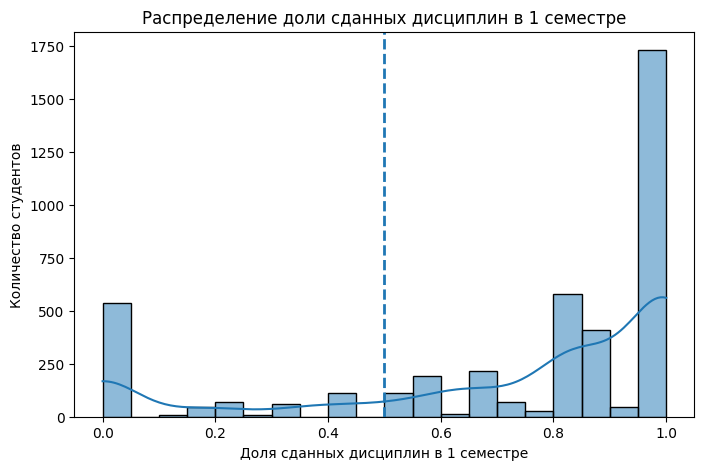

In [45]:
plt.figure(figsize=(8, 5))
sns.histplot(data_h1['approval_rate_1sem'], bins=20, kde=True)
plt.axvline(0.5, linestyle='--', linewidth=2)
plt.title('Распределение доли сданных дисциплин в 1 семестре')
plt.xlabel('Доля сданных дисциплин в 1 семестре')
plt.ylabel('Количество студентов')
plt.show()

Распределение имеет выраженные пики около 0 и около 1. В данных есть заметные группы студентов, которые либо почти не сдали дисциплины в первом семестре, либо сдали почти все дисциплины. Вертикальная линия показывает выбранный порог 0.5. Студенты левее этого порога относятся к группе низкого академического прогресса, так как они сдали менее половины дисциплин, на которые были записаны

In [46]:
h1_plot = data_h1.groupby('low_academic_progress_1sem')['is_dropout'].mean().reset_index()
h1_plot

,low_academic_progress_1sem,is_dropout
0,0,0.184040
1,1,0.847877


In [47]:
h1_plot['group'] = h1_plot['low_academic_progress_1sem'].map({0: 'Сдали 50% и более', 1: 'Сдали менее 50%'})
h1_plot['dropout_rate_percent'] = (h1_plot['is_dropout']*100).round(2)
h1_plot

,low_academic_progress_1sem,is_dropout,group,dropout_rate_percent
0,0,0.184040,Сдали 50% и более,18.40
1,1,0.847877,Сдали менее 50%,84.79


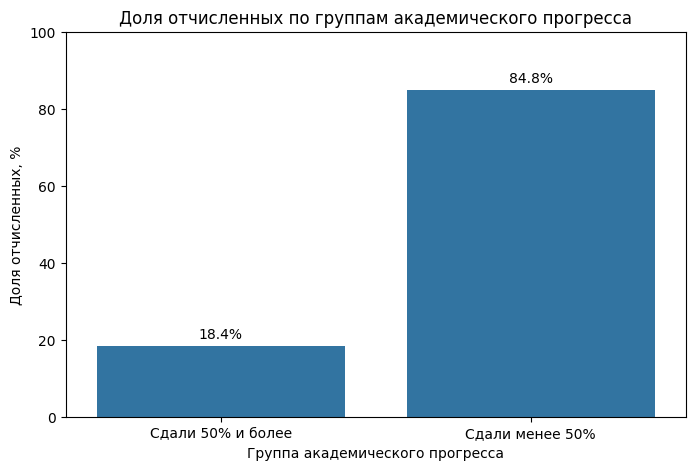

In [48]:
plt.figure(figsize=(8, 5))
sns.barplot(data=h1_plot, x='group', y='dropout_rate_percent')
plt.title('Доля отчисленных по группам академического прогресса')
plt.xlabel('Группа академического прогресса')
plt.ylabel('Доля отчисленных, %')
plt.ylim(0, 100)
for i, value in enumerate(h1_plot['dropout_rate_percent']):
    plt.text(i, value + 2, f'{value:.1f}%', ha='center')
plt.show()

In [49]:
h1_plot_2 = data_h1.copy()
h1_plot_2['dropout_group'] = h1_plot_2['is_dropout'].map({0: 'Не отчислился',1: 'Отчислился'})
h1_plot_2.head()

,Target,Curricular units 1st sem (approved),Curricular units 1st sem (enrolled),approval_rate_1sem,low_academic_progress_1sem,is_dropout,dropout_group
1,Graduate,6,6,1.000000,0,0,Не отчислился
2,Dropout,0,6,0.000000,1,1,Отчислился
3,Graduate,6,6,1.000000,0,0,Не отчислился
4,Graduate,5,6,0.833333,0,0,Не отчислился
5,Graduate,5,5,1.000000,0,0,Не отчислился


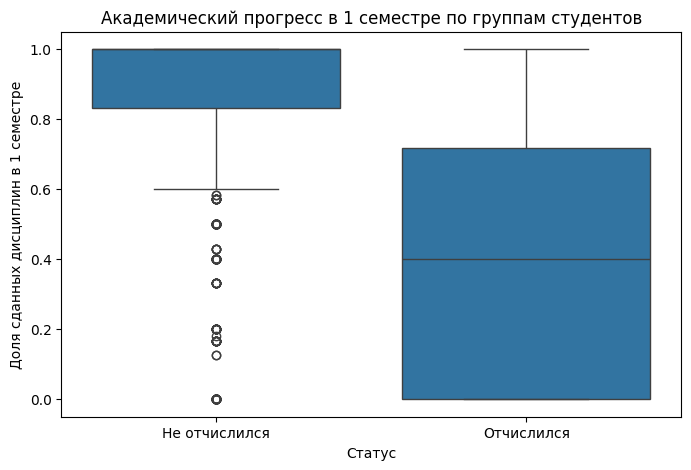

In [50]:
h1_plot_2['dropout_group'] = h1_plot_2['is_dropout'].map({0: 'Не отчислился',1: 'Отчислился'})
plt.figure(figsize=(8, 5))
sns.boxplot(data=h1_plot_2,x='dropout_group',y='approval_rate_1sem')
plt.title('Академический прогресс в 1 семестре по группам студентов')
plt.xlabel('Статус')
plt.ylabel('Доля сданных дисциплин в 1 семестре')
plt.show()

У студентов, которые не были отчислены, значения доли сданных дисциплин в первом семестре в основном сконцентрированы в верхней части шкалы. У студентов из группы `Dropout` распределение смещено ниже, медиана находится примерно около 0.4, а значительная часть наблюдений имеет очень низкий академический прогресс

#### Итог по гипотезе 1

На уровне значимости 5% мы отвергаем нулевую гипотезу о равенстве долей отчисления между группами.

Результат z-test для двух долей показал, что среди студентов с низким академическим прогрессом в первом семестре доля отчисленных статистически значимо выше, чем среди студентов, сдавших 50% и более дисциплин:

- z-statistic = 37.17
- p-value < 0.001

Среди студентов с низким академическим прогрессом отчислились около 84.8%, тогда как среди остальных студентов около 18.4%.

Абсолютный разрыв между этими долями составляет около 66.4 процентных пункта. 95% доверительный интервал для разницы долей составляет [0.6348, 0.6897], то есть истинная разница может находиться примерно в диапазоне от 63.5 до 69.0 процентных пункта.

Относительный риск равен примерно 4.61. Это означает, что доля отчисленных среди студентов с низким академическим прогрессом примерно в 4.6 раза выше, чем среди студентов, сдавших 50% и более дисциплин.

Таким образом низкий академический прогресс уже в первом семестре можно рассматривать как сильный ранний индикатор риска отчисления.

При этом результат показывает статистическую связь, а не доказывает причинность. Низкий академический прогресс может быть связан с другими факторами, по типу финансовыми трудностями, мотивацией, выбранной образовательной программой, личными обстоятельствами или общей учебной нагрузкой студента

### Гипотеза 2. Финансовые трудности и риск отчисления

В этой гипотезе проверим, связаны ли финансовые трудности студента с фактом отчисления.

В датасете есть два признака, которые описывают финансовое состояние студента `Debtor` и `Tuition fees up to date`.

`Tuition fees up to date` показывает, оплачено ли обучение студента вовремя.
- `1` - обучение оплачено вовремя
- `0` - обучение не оплачено вовремя (возможно, например есть просрочка, неоплаченный платеж или проблема с оплатой)

`Debtor` показывает, числится ли студент должником.
- `1` - студент числится должником
- `0` - студент не числится должником

Целевая переменная все такж факт отчисления:
- `1` - студент отчислился (`Dropout`)
- `0` - студент не отчислился (`Graduate` или `Enrolled`)

Все таки хочется понять, как связаны эти два фин признака между собой. На первый взгляд нам показалось, что они могут даже дублировать друг друга по смыслу. Нужно проверить и четко обозначить разницу

In [51]:
pd.crosstab(data['Debtor'], data['Tuition fees up to date'], margins=True)

Tuition fees up to date,0,1,All
Debtor,,,
0,282,3639,3921
1,246,257,503
All,528,3896,4424


Нельзя утверждать точно без документации вуза, но возможна разумная интерпретация такая:
- Большинство студентов не должники и с актуальной оплатой (3639)
- Есть студенты, у которых оплата не актуальна, но Debtor = 0 (282)
- Есть студенты, у которых Debtor = 1, но Tuition fees up to date = 1 (257)
- Есть студенты, у которых оба финансовых флага проблемные (246)

Значит, признаки связаны, но не дублируют друг друга

Можно интерпретировать разницу между ними так, что

Tuition fees up to date = 0 - проблема именно с оплатой обучения на момент фиксации данных

Debtor = 1 - студент имеет статус должника. это может быть более общий или административный статус

**Формулировка гипотезы:**  
Студенты с финансовым риском статистически чаще относятся к группе отчисленных, чем студенты без финансового риска.

Под финансовым риском понимаем ситуацию, когда выполняется хотя бы одно из условий:

- студент числится должником: `Debtor = 1`
- обучение не оплачено вовремя: `Tuition fees up to date = 0`

Для проверки гипотезы создадим общий бинарный индикатор финансового риска:
- `financial_risk = 1`, если студент имеет задолженность или обучение не оплачено вовремя (`Debtor = 1` или `Tuition fees up to date = 0`)
- `financial_risk = 0`, если задолженности нет и обучение оплачено вовремя (`Debtor = 0` и `Tuition fees up to date = 1`)

В этой гипотезе мы не утверждаем, что финансовые трудности являются причиной отчисления. Мы проверяем наличие статистической связи между финансовым риском и фактом отчисления

#### Подготовим данные для теста

In [52]:
data_h2 = data[['Target', 'Debtor', 'Tuition fees up to date']].copy()

In [53]:
target_groups = {'Graduate' : 0, 'Dropout' : 1, 'Enrolled' : 0}
data_h2['is_dropout'] = data_h2['Target'].map(target_groups)

In [54]:
data_h2['financial_risk'] = ((data_h2['Debtor'] == 1) | (data_h2['Tuition fees up to date'] == 0)).astype('int')

In [55]:
data_h2.head()

,Target,Debtor,Tuition fees up to date,is_dropout,financial_risk
0,Dropout,0,1,1,0
1,Graduate,0,0,0,1
2,Dropout,0,0,1,1
3,Graduate,0,1,0,0
4,Graduate,0,1,0,0


Посмотрим на распределения признаков

In [56]:
data_h2['financial_risk'].value_counts()

financial_risk
0    3639
1     785
Name: count, dtype: int64

In [57]:
data_h2['financial_risk'].value_counts(normalize=True)

financial_risk
0    0.822559
1    0.177441
Name: proportion, dtype: float64

То есть примерно 18% студентов имеют финансовый риск по нашему определению

Быстренько взглянем на описательную статистику по группам

In [58]:
pd.crosstab(data_h2['financial_risk'], data_h2['is_dropout'])

is_dropout,0,1
financial_risk,,
0,2772,867
1,231,554


In [59]:
pd.crosstab(data_h2['financial_risk'], data_h2['is_dropout'], margins=True)

is_dropout,0,1,All
financial_risk,,,
0,2772,867,3639
1,231,554,785
All,3003,1421,4424


In [60]:
data_h2.groupby('financial_risk')['is_dropout'].agg(['count', 'sum', 'mean']).rename(columns={'count':'n_students','sum': 'n_dropouts', 'mean':'dropout_rate'})

,n_students,n_dropouts,dropout_rate
financial_risk,,,
0,3639,867,0.238252
1,785,554,0.705732


Уже видно какое то различие между группами. Среди студентов без финансового риска отчислились около 23.8%. Среди студентов с финансовым риском отчислились около 70.6%. В группе финансового риска доля отчисленных значительно выше. Однако опять же описательная статистика сама по себе не доказывает статистическую связь, поэтому далее применим стат тест для более точной проверки

#### Формулировка статистических гипотез

**H0:** финансовый риск и факт отчисления независимы  

**H1:** финансовый риск и факт отчисления статистически связаны 

#### Выбор статистическего теста

В этой гипотезе обе переменные являются категориальными:

- `financial_risk`: есть финансовый риск или нет
- `is_dropout`: студент отчислился или нет

Для проверки независимости двух категориальных переменных подходит критерий хи-квадрат

Такой тест проверяет по сути, отличаются ли наблюдаемые частоты в таблице сопряженности от тех частот, которые ожидались бы при независимости переменных

#### Проверим условия применения теста

Для теста независимости важно, чтобы:

1. наблюдения были независимыми
2. переменные были категориальными
3. ожидаемые частоты в ячейках таблицы сопряженности не были слишком малыми

#### Хи квадрат тест независимости

In [61]:
h2_table = pd.crosstab(data_h2['financial_risk'], data_h2['is_dropout'])

In [62]:
observed_data = h2_table.copy()
observed_data.index = ['No financial risk', 'Financial risk']
observed_data.columns = ['Not dropout', 'Dropout']

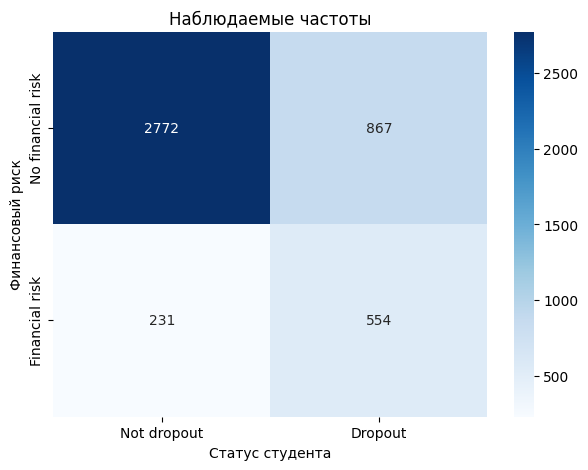

In [63]:
plt.figure(figsize=(7, 5))
sns.heatmap(observed_data, annot=True, fmt='d', cmap='Blues')
plt.title('Наблюдаемые частоты')
plt.xlabel('Статус студента')
plt.ylabel('Финансовый риск')
plt.show()

In [64]:
chi2, p, dof, expected = stats.chi2_contingency(h2_table)

In [65]:
chi2

np.float64(645.065706666479)

In [66]:
p

np.float64(2.6438023392715797e-142)

In [67]:
dof

1

In [68]:
expected

array([[2470.14398734, 1168.85601266],
       [ 532.85601266,  252.14398734]])

In [69]:
pd.DataFrame(expected, index=h2_table.index, columns=h2_table.columns)

is_dropout,0,1
financial_risk,,
0,2470.143987,1168.856013
1,532.856013,252.143987


Ожидаемые частоты во всех ячейках больше 5, поэтому условие применимости хи квадрат теста выполняется

In [70]:
p < 0.05

np.True_

In [71]:
p < 0.001

np.True_

Полученное значение хи квадрат статистики равно 645.07, а p-value даже меньше 0.001.

Так как p-value значительно меньше уровня значимости 0.05, мы отвергаем нулевую гипотезу о независимости финансового риска и факта отчисления.

Следовательно финансовый риск и факт отчисления статистически связаны

In [72]:
residuals = (h2_table - expected)/np.sqrt(expected)

In [73]:
residuals_data = pd.DataFrame(residuals.values, index=['No financial risk', 'Financial risk'], columns=['Not dropout', 'Dropout'])
residuals_data

,Not dropout,Dropout
No financial risk,6.073495,-8.829159
Financial risk,-13.076602,19.009711


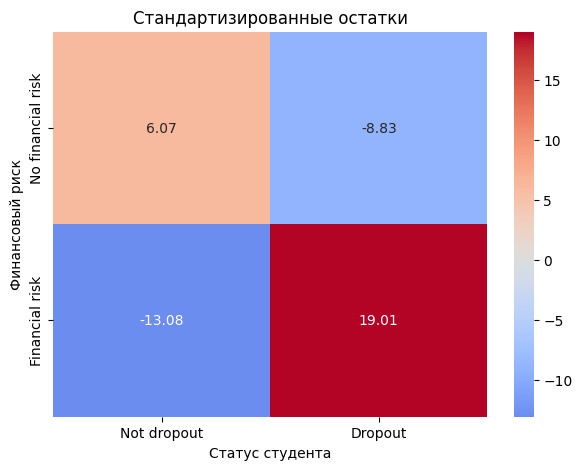

In [74]:
plt.figure(figsize=(7, 5))
sns.heatmap(residuals_data, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Стандартизированные остатки')
plt.xlabel('Статус студента')
plt.ylabel('Финансовый риск')
plt.show()

Стандартизированные остатки показывают, в каких ячейках наблюдаемые частоты сильнее всего отличаются от ожидаемых частот при условии независимости переменных.

Положительный остаток означает, что наблюдений в ячейке больше, чем ожидалось бы при независимости. Отрицательный остаток означает, что наблюдений меньше ожидаемого.

В нашем случае особенно важна ячейка `Financial risk - Dropout`. Положительный остаток показывает, что среди студентов с финансовым риском отчислений больше, чем ожидалось бы при независимости финансового риска и факта отчисления

Стандартизированные остатки подтверждают направление связи, что финансовый риск связан с более высокой долей отчислений

#### Оценка силы связи между признаками

p-value показывает, что связь между переменными статистически значима, но не показывает, насколько эта связь сильная

Для оценки силы связи между двумя категориальными переменными рассчитаем V Крамера

V Крамера принимает значения от 0 до 1:

- значение около 0 означает отсутствие связи
- чем ближе значение к 1, тем сильнее связь между переменными

In [75]:
n = h2_table.to_numpy().sum()

In [76]:
np.sqrt(chi2/(n*(min(h2_table.shape)-1)))

np.float64(0.3818514270718378)

V Крамера равен примерно 0.382. Это показывает, что связь между финансовым риском и фактом отчисления не является случайной или пренебрежимо малой. Можно сказать, что сила связи умеренная, средняя

#### Разница долей

Дополнительно рассчитаем разницу долей и относительный риск, чтобы интерпретировать результат в терминах dropout rate

In [77]:
h2_extra = data_h2.groupby('financial_risk')['is_dropout'].agg(['count', 'sum', 'mean']).rename(columns={'count':'n_students','sum': 'n_dropouts', 'mean':'dropout_rate'})
h2_extra

,n_students,n_dropouts,dropout_rate
financial_risk,,,
0,3639,867,0.238252
1,785,554,0.705732


In [78]:
plot_data = h2_extra.reset_index()
plot_data['financial_risk_label'] = plot_data['financial_risk'].map({0: 'no financial risk', 1: 'financial risk'})
plot_data['dropout_rate_percent'] = (plot_data['dropout_rate']*100).round(2)
plot_data

,financial_risk,n_students,n_dropouts,dropout_rate,financial_risk_label,dropout_rate_percent
0,0,3639,867,0.238252,no financial risk,23.83
1,1,785,554,0.705732,financial risk,70.57


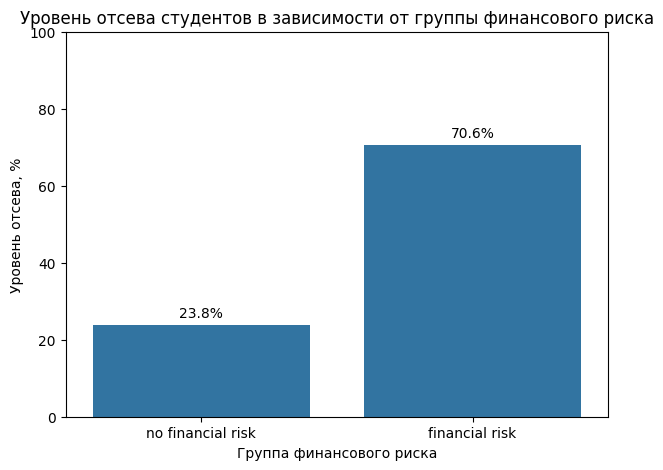

In [79]:
plt.figure(figsize=(7, 5))
sns.barplot(data=plot_data, x='financial_risk_label', y='dropout_rate_percent')
plt.title('Уровень отсева студентов в зависимости от группы финансового риска')
plt.xlabel('Группа финансового риска')
plt.ylabel('Уровень отсева, %')
plt.ylim(0, 100)
for i, value in enumerate(plot_data['dropout_rate_percent']):
    plt.text(i, value + 2, f'{value:.1f}%', ha='center')
plt.show()

In [80]:
h2_extra.loc[1, 'dropout_rate'] - h2_extra.loc[0, 'dropout_rate']

np.float64(0.4674802169700852)

In [81]:
h2_extra.loc[1, 'dropout_rate'] / h2_extra.loc[0, 'dropout_rate']

np.float64(2.9621228483900115)

Cреди студентов с финансовым риском отчислились около 70.6%. А среди студентов без финансового риска отчислились около 23.8%. Абсолютный разрыв между долями составляет около 46.8 процентных пункта. А доля отчисленных среди студентов с финансовым риском примерно в 3 раза выше, чем среди студентов без финансового риска

#### Итог по гипотезе 2

На уровне значимости 5% мы отвергаем нулевую гипотезу о независимости финансового риска и факта отчисления.

хи квадрат тест независимости показал, что финансовый риск статистически связан с фактом отчисления:

- хи квадрат статистика = 645.07
- p-value < 0.001
- V Крамера = 0.382

Среди студентов с финансовым риском отчислились около 70.6%, тогда как среди студентов без финансового риска около 23.8%.

Абсолютный разрыв между долями составляет около 46.8 процентных пункта. Относительный риск равен примерно 2.96, то есть доля отчисленных среди студентов с финансовым риском примерно в 3 раза выше, чем среди студентов без финансового риска

Финансовый риск можно рассматривать как важный фактор, статистически связанный с отчислением.

При этом результат показывает связь, но не доказывает причинность. Финансовый риск может быть связан с другими характеристиками студента (по типу академ. успеваемостью, возрастом, занятостью, выбранной программой или соц-эконом положением)

#### Сравнительный анализ нескольких статистических подходов для гипотезы 2

Для гипотезы о связи финансового риска и отчисления дополнительно сравним несколько подходов. Основным тестом остается хи квадрат тест независимости, так как обе переменные категориальные и ожидаемые частоты достаточно велики. Но для проверки устойчивости вывода применим также точный тест Фишера, z-test для двух долей и простую логистическую регрессию

In [82]:
fisher_table_h2 = pd.crosstab(data_h2['financial_risk'],data_h2['is_dropout']).loc[[1, 0], [1, 0]]
fisher_table_h2

is_dropout,1,0
financial_risk,,
1,554,231
0,867,2772


In [83]:
odds_ratio_fisher_h2, p_fisher_h2 = stats.fisher_exact(fisher_table_h2, alternative='two-sided')

In [84]:
odds_ratio_fisher_h2

np.float64(7.6678200692041525)

In [85]:
p_fisher_h2

np.float64(8.126465249896081e-134)

In [86]:
counts_h2 = [h2_extra.loc[1, 'n_dropouts'], h2_extra.loc[0, 'n_dropouts']]
nobs_h2 = [h2_extra.loc[1, 'n_students'], h2_extra.loc[0, 'n_students']]
z_h2, p_z_h2 = proportions_ztest(count=counts_h2, nobs=nobs_h2, alternative='larger')

In [87]:
z_h2, p_z_h2

(np.float64(25.440283530276528), np.float64(4.521499362036062e-143))

In [88]:
model_h2_simple = smf.logit(formula='is_dropout ~ financial_risk', data=data_h2).fit(disp=False)

In [89]:
or_h2_logit = np.exp(model_h2_simple.params['financial_risk'])
ci_h2_logit = np.exp(model_h2_simple.conf_int().loc['financial_risk'])
p_h2_logit = model_h2_simple.pvalues['financial_risk']

In [90]:
or_h2_logit

np.float64(7.667820069204139)

In [91]:
ci_h2_logit

0    6.459976
1    9.101499
Name: financial_risk, dtype: float64

In [92]:
p_h2_logit

np.float64(5.268886594657183e-120)

Все четыре подхода приводят к одному содержательному выводу, финансовый риск статистически связан с более высокой вероятностью попадания студента в группу `Dropout`

### Гипотеза 3. Возраст при поступлении и риск отчисления при учете академического прогресса и предыдущей образовательной траектории

В этой гипотезе проверим, связан ли возраст студента при поступлении с риском отчисления даже после учета академического прогресса в первом семестре и предыдущей образовательной квалификации.

**Формулировка гипотезы:**  
студенты, поступившие в возрасте 23 лет и старше, имеют более высокие шансы попасть в группу отчисленных по сравнению со студентами 17-22 лет даже после учета доли сданных дисциплин в первом семестре и предыдущей образовательной квалификации.

Мы не утверждаем, что возраст сам по себе является причиной отчисления. Мы проверяем, сохраняется ли статистическая связь между возрастной группой 23+ и фактом отчисления после учета других важных факторов.


В этой гипотезе все та же целевая переменная бинарная:

- `1` - студент отчислился (`Dropout`);
- `0` - студент не отчислился (`Graduate` или `Enrolled`).

Обычное сравнение долей между возрастными группами показало бы только общую разницу в dropout rate. Но наша гипотеза строже, мы хотим проверить, сохраняется ли связь возраста с отчислением при сопоставимом академическом прогрессе и с учетом предыдущей образовательной траектории.

Поэтому используем логистическую регрессию. Она подходит, когда зависимая переменная бинарная, и позволяет оценить связь фактора с вероятностью события при контроле других переменных

Будут использоваться следующие признаки:

|Признак|Смысл|
|---|---|
|`Target`|итоговый статус студента|
|`Age at enrollment`|возраст студента при поступлении|
|`Curricular units 1st sem (approved)`|количество сданных дисциплин в 1 семестре|
|`Curricular units 1st sem (enrolled)`|количество дисциплин, на которые студент был записан в 1 семестре|
|`Previous qualification`|предыдущая образовательная квалификация студента|

На основе этих признаков создадим:

- `is_dropout` - бинарный индикатор отчисления
- `approval_rate_1sem` - доля сданных дисциплин в 1 семестре
- `age_23_plus` - индикатор поступления в возрасте 23+
- `non_standard_previous_qualification` - индикатор нестандартной предыдущей образовательной траектории

Признак `Previous qualification` является категориальным кодом, а не количественной переменной. Поэтому его нельзя интерпретировать как обычное число. В базовой категории `1` указано стандартное среднее образование, остальные значения отражают другие варианты предыдущей квалификации

#### Подготовим данные для теста

In [93]:
data_h3 = data[['Target', 'Age at enrollment','Previous qualification', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (enrolled)']].copy()

In [94]:
target_groups = {'Graduate' : 0, 'Dropout' : 1, 'Enrolled' : 0}
data_h3['is_dropout'] = data_h3['Target'].map(target_groups)

In [95]:
data_h3.head()

,Target,Age at enrollment,Previous qualification,Curricular units 1st sem (approved),Curricular units 1st sem (enrolled),is_dropout
0,Dropout,20,1,0,0,1
1,Graduate,19,1,6,6,0
2,Dropout,19,1,0,6,1
3,Graduate,20,1,6,6,0
4,Graduate,45,1,5,6,0


Как и в первой гипотезе, для расчета `approval_rate_1sem` нужно исключить студентов, у которых количество дисциплин, на которые они были записаны в первом семестре, равно нулю. Для таких студентов невозможно корректно рассчитать долю сданных дисциплин

In [96]:
data_h3 = data_h3[data_h3['Curricular units 1st sem (enrolled)'] > 0]

In [97]:
data_h3['approval_rate_1sem'] = data_h3['Curricular units 1st sem (approved)']/data_h3['Curricular units 1st sem (enrolled)']

Теперь создадим возрастную группу.
В гипотезе сравниваются:

- студенты 17-22 лет
- студенты 23 лет и старше

In [98]:
data_h3['Age at enrollment'].describe()

count    4244.000000
mean       23.397738
std         7.684054
min        17.000000
25%        19.000000
50%        20.000000
75%        25.000000
max        70.000000
Name: Age at enrollment, dtype: float64

In [99]:
data_h3['age_group'] = pd.cut(data_h3['Age at enrollment'], bins=[data_h3['Age at enrollment'].min() - 1, 22, data_h3['Age at enrollment'].max() + 1], labels=['17-22', '23+'], right=True)

In [100]:
data_h3['age_23_plus'] = (data_h3['age_group'] =='23+').astype('int')

In [101]:
data_h3.head()

,Target,Age at enrollment,Previous qualification,Curricular units 1st sem (approved),Curricular units 1st sem (enrolled),is_dropout,approval_rate_1sem,age_group,age_23_plus
1,Graduate,19,1,6,6,0,1.000000,17-22,0
2,Dropout,19,1,0,6,1,0.000000,17-22,0
3,Graduate,20,1,6,6,0,1.000000,17-22,0
4,Graduate,45,1,5,6,0,0.833333,23+,1
5,Graduate,50,19,5,5,0,1.000000,23+,1


In [102]:
data_h3['age_group'].value_counts()

age_group
17-22    2886
23+      1358
Name: count, dtype: int64

In [103]:
data_h3.groupby('age_group')['is_dropout'].agg(['count', 'sum', 'mean']).rename(columns={'count': 'n_students', 'sum': 'n_dropouts', 'mean': 'dropout_rate'})

,n_students,n_dropouts,dropout_rate
age_group,,,
17-22,2886,630,0.218295
23+,1358,714,0.525773


Среди студентов 17-22 лет доля отчисленных составляет около 21.8%, тогда как среди студентов 23 лет и старше около 52.6%.

Но это сравнение пока не учитывает академический прогресс в первом семестре и предыдущую образовательную траекторию

Также создадим упрощенный индикатор предыдущей образовательной траектории.

`Previous qualification = 1` соответствует стандартному среднему образованию. Остальные значения будем рассматривать как нестандартную предыдущую квалификацию. Например уже имеющееся высшее образование, незавершенное образование, профессиональная или техническая квалификация.

Если использовать все категории `Previous qualification` отдельно, часть категорий может оказаться слишком редкой. Поэтому мы укрупняем категории

In [104]:
data_h3['non_standard_previous_qualification'] = (data_h3['Previous qualification'] != 1).astype('int')

Проверим, отличаются ли возрастные группы по академическому прогрессу в первом семестре

In [105]:
data_h3.groupby('age_group')['approval_rate_1sem'].agg(['count', 'mean', 'median', 'std']).round(3)

,count,mean,median,std
age_group,,,,
17-22,2886,0.797,0.875,0.292
23+,1358,0.580,0.714,0.393


студенты 17-22 лет в среднем сдали около 79.7% дисциплин в первом семестре. студенты 23+ в среднем сдали около 58.0% дисциплин. Медиана тоже ниже у группы 23+ (0.714 против 0.875)

Простое сравнение dropout rate между возрастными группами может быть частично связано не с возрастом как таковым, а с различиями в академическом прогрессе. Поэтому `approval_rate_1sem` необходимо включить в модель как контрольную переменную

Теперь посмотрим, отличаются ли возрастные группы по предыдущей образовательной квалификации

In [106]:
pd.crosstab(data_h3['age_group'], data_h3['non_standard_previous_qualification'], margins=True)

non_standard_previous_qualification,0,1,All
age_group,,,
17-22,2689,197,2886
23+,861,497,1358
All,3550,694,4244


In [107]:
pd.crosstab(data_h3['age_group'], data_h3['non_standard_previous_qualification'], normalize='index')

non_standard_previous_qualification,0,1
age_group,,
17-22,0.931739,0.068261
23+,0.634021,0.365979


Возрастные группы также отличаются по предыдущей образовательной квалификации.

Среди студентов 17-22 лет нестандартная предыдущая квалификация встречается примерно у 6.8% студентов. Среди студентов 23+ примерно у 36.6%.

Это подтверждает, что возрастная группа 23+ отличается от группы 17-22 не только возрастом, но и образовательной траекторией до поступления. Поэтому `non_standard_previous_qualification` также нужно учитывать в модели

In [108]:
data_h3.head()

,Target,Age at enrollment,Previous qualification,Curricular units 1st sem (approved),Curricular units 1st sem (enrolled),is_dropout,approval_rate_1sem,age_group,age_23_plus,non_standard_previous_qualification
1,Graduate,19,1,6,6,0,1.000000,17-22,0,0
2,Dropout,19,1,0,6,1,0.000000,17-22,0,0
3,Graduate,20,1,6,6,0,1.000000,17-22,0,0
4,Graduate,45,1,5,6,0,0.833333,23+,1,0
5,Graduate,50,19,5,5,0,1.000000,23+,1,1


### Выбор статистического теста

В этой гипотезе зависимая переменная `is_dropout` является бинарной:

- `1` - студент отчислился
- `0` - студент не отчислился

Для такой переменной обычная линейная регрессия не подходит. Она может давать предсказания меньше 0 или больше 1 и не учитывает бинарную природу исхода.

Логистическая регрессия подходит для моделирования вероятности бинарного события. В нашем случае она оценивает вероятность того, что студент попадёт в группу `Dropout`.

Модель позволяет проверить, остается ли возрастная группа 23+ связанной с отчислением после учета других факторов:

is_dropout ~ age_23_plus + approval_rate_1sem + non_standard_previous_qualification

Где:

- `age_23_plus` - основной интересующий фактор
- `approval_rate_1sem` - контроль академического прогресса
- `non_standard_previous_qualification` - контроль предыдущей образовательной траектории

### Формулировка статистических гипотез

Мы хотим проверить связь возраста после учета других факторов. Поэтому объектом проверки становится коэффициент при переменной `age_23_plus` в логистической регрессии

$$
\operatorname{logit}\left(P(is\_dropout = 1)\right) = \beta_0 + \beta_1 \cdot age\_23\_plus + \beta_2 \cdot approval\_rate\_1sem + \beta_3 \cdot non\_standard\_previous\_qualification
$$

где:

- $P(is\_dropout = 1)$ - вероятность того, что студент отчислится
- $\beta_0$ - свободный член модели
- $\beta_1$ - коэффициент при возрастной группе 23+
- $\beta_2$ - коэффициент при академическом прогрессе в 1 семестре
- $\beta_3$ - коэффициент при нестандартной предыдущей квалификации

Коэффициент $\beta_1$ показывает, как меняются логарифмические шансы отчисления для студентов 23+ по сравнению со студентами 17-22 при одинаковых значениях остальных переменных в модели. Поэтому статистическая гипотеза формулируется именно для этого коэффициента

Тогда 
Нулевая гипотеза: H_0: $\beta_1$ = 0

То есть после учета академического прогресса в первом семестре и предыдущей образовательной траектории возрастная группа 23+ не связана с шансами отчисления.

Альтернативная гипотеза: H_1: $\beta_1$ != 0

После учета академического прогресса и предыдущей образовательной траектории возрастная группа 23+ статистически связана с шансами отчисления

Тест проводится как двусторонний, потому что формально проверяется наличие связи. При этом содержательно ожидаемое направление связи положительное, для студентов 23+ шансы отчисления должны быть выше по идее

In [109]:
model_h3 = smf.logit(formula='is_dropout ~ age_23_plus + approval_rate_1sem + non_standard_previous_qualification', data=data_h3).fit()

Optimization terminated successfully.
         Current function value: 0.400674
         Iterations 6


In [110]:
model_h3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             is_dropout   No. Observations:                 4244
Model:                          Logit   Df Residuals:                     4240
Method:                           MLE   Df Model:                            3
Date:                Thu, 21 May 2026   Pseudo R-squ.:                  0.3582
Time:                        20:09:26   Log-Likelihood:                -1700.5
converged:                       True   LL-Null:                       -2649.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               2.1239      0.125     17.013      0.000       1.879       2.369
age_23_plus                             0.8540      0.096      8.936      0.000       0.667       1.041
approval_rate_1sem                     -4.6574      0.154    -30.292      0.000      -4.959      -4.356
non_standard_previous_qualification     0.2390      0.120      1.993      0.046       0.004       0.474
=======================================================================================================
"""

Выведем отношение шансов (Odds Ratio, OR). Это нужно, чтобы понятнее интерпретировать коэффициенты логистической регрессии: OR показывает, во сколько раз меняются шансы попадания в группу `Dropout` при изменении признака

In [111]:
params = model_h3.params
params

Intercept                              2.123907
age_23_plus                            0.853991
approval_rate_1sem                    -4.657428
non_standard_previous_qualification    0.238954
dtype: float64

In [112]:
conf = model_h3.conf_int()
conf

,0,1
Intercept,1.879231,2.368583
age_23_plus,0.666692,1.041291
approval_rate_1sem,-4.958779,-4.356078
non_standard_previous_qualification,0.003942,0.473966


In [113]:
h3_odds_ratios = pd.DataFrame({'odds_ratio': np.exp(params), 'ci_low': np.exp(conf[0]), 'ci_high': np.exp(conf[1]), 'p_value': model_h3.pvalues})
h3_odds_ratios

,odds_ratio,ci_low,ci_high,p_value
Intercept,8.363751,6.548465,10.682250,6.531859e-65
age_23_plus,2.349004,1.947782,2.832873,4.019514e-19
approval_rate_1sem,0.009491,0.007021,0.012829,1.478247e-201
non_standard_previous_qualification,1.269920,1.003949,1.606352,4.627941e-02


В таблице коэффициенты логистической регрессии переведены в odds ratio, чтобы их было проще интерпретировать.

Основной интерес представляет переменная `age_23_plus`. Для нее odds ratio равен примерно 2.35, а p-value < 0.001. Доверительный интервал [1.95, 2.83] полностью выше 1.

После учета академического прогресса в первом семестре и предыдущей образовательной траектории студенты 23 лет и старше имеют статистически значимо более высокие шансы отчисления по сравнению со студентами 17-22 лет.

Переменная `approval_rate_1sem` имеет odds ratio меньше 1 и p-value < 0.001. Более высокий академический прогресс в первом семестре связан со снижением шансов отчисления.

Переменная `non_standard_previous_qualification` также имеет odds ratio больше 1 и p-value = 0.046. Однако этот эффект слабее и находится близко к границе статистической значимости, поэтому его следует интерпретировать осторожно.

Связь между возрастной группой 23+ и отчислением сохраняется даже после учета академического прогресса и предыдущей образовательной траектории

Чтобы сделать интерпретацию модели более наглядной, рассчитаем предсказанные вероятности отчисления для разных сценариев.

Мы сравним студентов 17-22 и 23+ при одинаковых значениях академического прогресса в первом семестре. Дополнительно покажем расчеты отдельно для стандартной и нестандартной предыдущей квалификации

In [114]:
prediction_grid = pd.DataFrame({'age_23_plus': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1], 'approval_rate_1sem': [0.5, 0.5, 0.75, 0.75, 1.0, 1.0,0.5, 0.5, 0.75, 0.75, 1.0, 1.0], 'non_standard_previous_qualification': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]})

In [115]:
prediction_grid['age_group'] = prediction_grid['age_23_plus'].map({0: '17-22', 1: '23+'})
prediction_grid['previous_qualification_group'] = prediction_grid['non_standard_previous_qualification'].map({0: 'standard previous qualification', 1: 'non-standard previous qualification'})

In [116]:
prediction_grid

,age_23_plus,approval_rate_1sem,non_standard_previous_qualification,age_group,previous_qualification_group
0,0,0.50,0,17-22,standard previous qualification
1,1,0.50,0,23+,standard previous qualification
2,0,0.75,0,17-22,standard previous qualification
3,1,0.75,0,23+,standard previous qualification
4,0,1.00,0,17-22,standard previous qualification
5,1,1.00,0,23+,standard previous qualification
6,0,0.50,1,17-22,non-standard previous qualification
7,1,0.50,1,23+,non-standard previous qualification
8,0,0.75,1,17-22,non-standard previous qualification
9,1,0.75,1,23+,non-standard previous qualification


In [117]:
prediction_grid['predicted_dropout_probability'] = model_h3.predict(prediction_grid[['age_23_plus', 'approval_rate_1sem', 'non_standard_previous_qualification']])

In [118]:
prediction_grid

,age_23_plus,approval_rate_1sem,non_standard_previous_qualification,age_group,previous_qualification_group,predicted_dropout_probability
0,0,0.50,0,17-22,standard previous qualification,0.448976
1,1,0.50,0,23+,standard previous qualification,0.656827
2,0,0.75,0,17-22,standard previous qualification,0.202755
3,1,0.75,0,23+,standard previous qualification,0.373982
4,0,1.00,0,17-22,standard previous qualification,0.073541
5,1,1.00,0,23+,standard previous qualification,0.157158
6,0,0.50,1,17-22,non-standard previous qualification,0.508536
7,1,0.50,1,23+,non-standard previous qualification,0.708506
8,0,0.75,1,17-22,non-standard previous qualification,0.244122
9,1,0.75,1,23+,non-standard previous qualification,0.431381


In [119]:
prediction_grid['predicted_dropout_probability_percent'] =(prediction_grid['predicted_dropout_probability']*100).round(2)

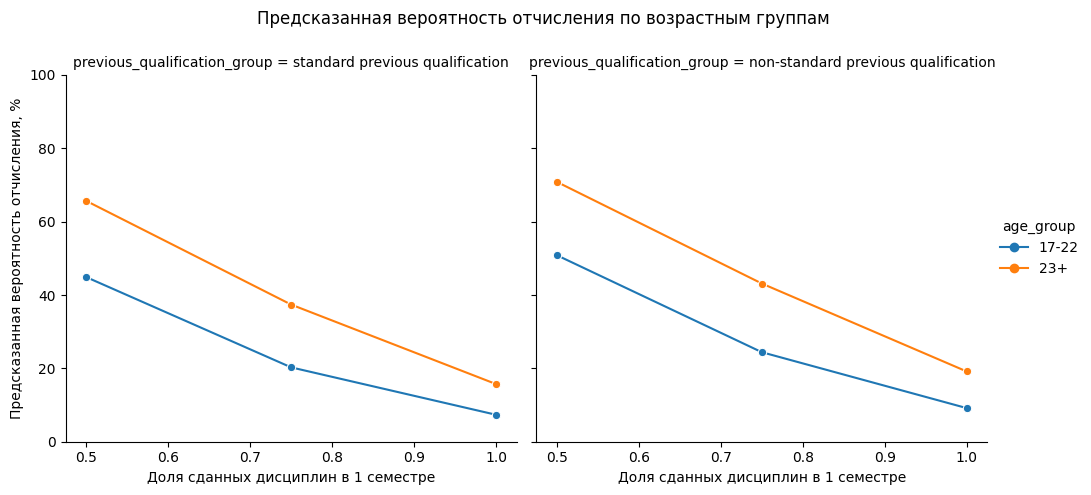

In [120]:
g = sns.relplot(data=prediction_grid,x='approval_rate_1sem', y='predicted_dropout_probability_percent', hue='age_group', col='previous_qualification_group', kind='line', marker='o', height=5, aspect=1)
g.set_axis_labels('Доля сданных дисциплин в 1 семестре', 'Предсказанная вероятность отчисления, %')
g.set(ylim=(0, 100))
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Предсказанная вероятность отчисления по возрастным группам')
plt.show()

Во всех рассмотренных сценариях при одинаковом академическом прогрессе вероятность отчисления выше для студентов 23+, чем для студентов 17-22.

Например, при `approval_rate_1sem = 0.75` и стандартной предыдущей квалификации модель оценивает вероятность отчисления как 20.3% для студентов 17-22 и 37.4% для студентов 23+.

Такая же закономерность сохраняется и для студентов с нестандартной предыдущей квалификацией: при `approval_rate_1sem = 0.75` предсказанная вероятность отчисления составляет 24.4% для группы 17-22 и 43.1% для группы 23+.

Также видно что при росте `approval_rate_1sem` предсказанная вероятность отчисления снижается во всех группах. Это согласуется с результатом модели

#### Итог по гипотез 3

На уровне значимости 5% мы отвергаем нулевую гипотезу о том, что возрастная группа 23+ не связана с шансами отчисления после учета академического прогресса в первом семестре и предыдущей образовательной траектории.

Логистическая регрессия показала, что переменная `age_23_plus` остается статистически значимой после добавления контрольных переменных:

- `approval_rate_1sem` - доля сданных дисциплин в первом семестре-
- `non_standard_previous_qualification` - индикатор нестандартной предыдущей квалификации.

Коэффициент при `age_23_plus` положительный, p-value < 0.001, а odds ratio составляет примерно 2.35. При сопоставимом академическом прогрессе и одинаковом типе предыдущей квалификации шансы отчисления у студентов 23 лет и старше примерно в 2.35 раза выше, чем у студентов 17-22 лет.

95% доверительный интервал для odds ratio по переменной `age_23_plus` составляет [1.95, 2.83]. Так как интервал полностью выше 1, это дополнительно подтверждает статистически значимую положительную связь между возрастной группой 23+ и шансами отчисления.

Также модель показала, что `approval_rate_1sem` имеет сильную отрицательную связь с отчислением. Чем выше доля сданных дисциплин в первом семестре, тем ниже шансы попасть в группу `Dropout`.

Признак `non_standard_previous_qualification` также положительно связан с шансами отчисления, однако этот эффект слабее и находится ближе к границе статистической значимости: p-value = 0.046, odds ratio ~ 1.27.


Возраст при поступлении можно рассматривать как фактор, статистически связанный с отчислением даже после учета академического прогресса в первом семестре и предыдущей образовательной траектории.

При этом результат не доказывает причинность. Более старший возраст может быть связан с другими обстоятельствами такими, как работой параллельно с учебой, семейными обязанностями, финансовой нагрузкой, перерывом в обучении, сменой образовательной траектории или другими ненаблюдаемыми факторами

## Используемые источники и литература

- [Z-test: как его проводят и в чем отличие от T-test](https://practicum.yandex.ru/blog/z-test-proverka-gipotez/)
- [Two-sample Proportion Test (Z test) in Python](https://stataiml.com/posts/53_two_sample_prop_test_py/)
- [statsmodels.stats.proportion.proportions_ztest](https://www.statsmodels.org/dev/generated/statsmodels.stats.proportion.proportions_ztest.html)
- [statsmodels.stats.proportion.confint_proportions_2indep](https://www.statsmodels.org/dev/generated/statsmodels.stats.proportion.confint_proportions_2indep.html)
- [Семейство тестов хи-квадрат: что у них под капотом и какие выбрать для сравнения воронок](https://habr.com/ru/companies/mygames/articles/677074/)
- [Критерий Пирсона: проверка гипотез и анализ данных на Python](https://sky.pro/wiki/python/primery-rascheta-kriteriya-pirsona-na-python/)
- [Подробный практический гайд по статистике на Python](https://uproger.com/podrobnyj-prakticheskij-gajd-po-statistike-na-python/)
- [Регрессионный анализ](https://nafi.ru/upload/spss/Lection_7.pdf)
- [Binary Logistic Regression](https://online.stat.psu.edu/stat504/Lesson06)
- [statsmodels.formula.api.logit](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.logit.html)
- [Logistic Regression in Python with statsmodels](https://www.andrewvillazon.com/logistic-regression-python-statsmodels/)
- [Отношение шансов](https://ru.wikipedia.org/wiki/%D0%9E%D1%82%D0%BD%D0%BE%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D1%88%D0%B0%D0%BD%D1%81%D0%BE%D0%B2)
- [fisher_exact](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fisher_exact.html)